# E-commerce Classification: Baseline Selection & Tuning

This notebook uses a **Two-Stage** approach:
1. **Baseline Evaluation**: Train all candidate models with default parameters to identify the most promising architectures.
2. **Hyperparameter Tuning**: Use Optuna to optimize ONLY the **Top 5** performing baseline models.
3. **Ensemble**: Build Stacking and Voting ensembles from the tuned top models.

## Candidate Models
- Logistic Regression, Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVM, KNN

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')

## 1. Data Loading & Preprocessing

In [19]:
train_df = pd.read_csv('data/train_df.csv')
test_df = pd.read_csv('data/test_df.csv')
train_df.info()
target = 'Reached.on.Time_Y.N'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8799 entries, 0 to 8798
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   8799 non-null   int64 
 1   Warehouse_block      8799 non-null   object
 2   Mode_of_Shipment     8799 non-null   object
 3   Customer_care_calls  8799 non-null   int64 
 4   Customer_rating      8799 non-null   int64 
 5   Cost_of_the_Product  8799 non-null   int64 
 6   Prior_purchases      8799 non-null   int64 
 7   Product_importance   8799 non-null   object
 8   Gender               8799 non-null   object
 9   Discount_offered     8799 non-null   int64 
 10  Weight_in_gms        8799 non-null   int64 
 11  Reached.on.Time_Y.N  8799 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 825.0+ KB


In [20]:
from sklearn.preprocessing import LabelEncoder

def apply_feature_engineering(df):
    # 1. Discount_Group 생성
    df['Discount_Group'] = (df['Discount_offered'] > 10).astype(int)
    
    # 2. Weight_Category 생성
    conditions = [
    (df['Weight_in_gms'] >= 4000) & (df['Weight_in_gms'] < 6000), 
    (df['Weight_in_gms'] >= 0) & (df['Weight_in_gms'] < 2000)     
    ]

    # 해당 조건에 대응하는 값 리스트
    choices = [0, 1]
    # 위의 조건들에 해당하지 않는 나머지(2000~4000 및 6000 이상)는 default 값 2으로 할당
    df['Weight_Category'] = np.select(conditions, choices, default=2)
   

    # 3. 창고별 배송수단 조합 
    df['Wh_Shipment_Combo'] = df['Warehouse_block'].astype(str) + '_' + df['Mode_of_Shipment'].astype(str)
    
    # 모델 학습을 위해 범주형을 숫자로 매핑 (Label Encoding과 유사)
    # AutoGluon을 쓰신다면 문자열 그대로 두어도 되지만, Scikit-learn 모델을 위해 숫자로 변환합니다.
    le = LabelEncoder()
    df['Wh_Shipment_Combo'] = le.fit_transform(df['Wh_Shipment_Combo']) + 1


    # 4. prior purchase 6이상 묶기
    df['Prior_purchases'] = df['Prior_purchases'].clip(upper=6)

    # 5. customer care call 범주 정리
    df['Customer_care_calls'] = df['Customer_care_calls'].clip(lower=3, upper=6)


    # 6. Discounted_price 생성
    df['Discounted_price'] = df['Cost_of_the_Product'] - df['Discount_offered']

    # 7. log_price_per_weight 생성
    df['Price_per_weight'] = df['Cost_of_the_Product'] / (df['Weight_in_gms'] / 1000)
    df['log_price_per_weight'] = np.log(df['Price_per_weight'])
    # 지연율과의 관계가 2차함수의 움직임을 따라가므로 polynomial을 판다스로 구현
    df['log_price_per_weight_sq'] =df['log_price_per_weight'] ** 2


    # 8. 할인율 Discount_rate 생성 
    df['Discount_rate'] = (df['Discount_offered'] / df['Cost_of_the_Product'])*100

    # 9. 화물 관리 레벨 Management_score 생성
    df['Management_score'] = (df['Customer_care_calls'] / df['Price_per_weight']) * ((df['Weight_in_gms']/1000)**1.5)
    # 지연율과의 관계가 2차함수의 움직임을 따라가므로 polynomial을 판다스로 구현
    df['Management_score_sq'] = df['Management_score'] ** 2

    return df

# 각각의 데이터셋에 적용
train_df = apply_feature_engineering(train_df)
test_df = apply_feature_engineering(test_df)


중복 특성 정리

'Wh_Shipment_Combo': 'Warehouse_block', 'Mode_of_Shipment' <br>
'Weight_in_gms': 'Weight_Category' <br>
'Cost_of_the_Product': 'Discounted_price' <br>
'Discount_offered': 'Discount_rate', 'Discount_Group' <br>
'Price_per_weight': 'log_price_per_weight'

In [21]:
drop_columns = ["ID", "Gender", "Customer_rating"] #"Discount_offered", "Weight_in_gms",'Warehouse_block', 'Mode_of_Shipment', 'Customer_rating'
train_df = train_df.drop(drop_columns, axis=1)
test_df = test_df.drop(drop_columns, axis=1)

# [설정] 이번 실험의 이름을 지정하세요 (예: 'All Features', 'Drop Outliers' 등)
current_experiment_name = 'base' 

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder



def apply_feature_preprocessing(df):

    # 1. Product_importance: Label Encoding (순서가 있으므로 수동 매핑)
    importance_map = {'low': 0, 'medium': 1, 'high': 2}
    df['Product_importance'] = df['Product_importance'].map(importance_map)

    # 2. One-Hot Encoding (Warehouse_block, Mode_of_Shipment, Wh_Shipment_Combo)
    df = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment'])

    return df
    
# 각각의 데이터셋에 적용
train_df = apply_feature_preprocessing(train_df)
test_df = apply_feature_preprocessing(test_df)



In [24]:
# Scaling 대상 컬럼 선정
num_features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms', 'Discounted_price', 'Price_per_weight', 'log_price_per_weight', 
                    'Discount_rate', 'Management_score', 'log_price_per_weight_sq', 'Management_score_sq']

scaler = StandardScaler()

# 중요: fit은 오직 train_df에만 수행합니다!
train_df[num_features] = scaler.fit_transform(train_df[num_features])

# test는 transform만 수행하여 데이터 누수를 차단합니다.
test_df[num_features] = scaler.transform(test_df[num_features])

In [25]:
# train_df를 X_train, y_train, X_val, y_val으로 분리

target = 'Reached.on.Time_Y.N'
X = train_df.drop(target, axis=1)
y = train_df[target]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
selected_cols = train_df.columns.tolist()
selected_cols

['Customer_care_calls',
 'Cost_of_the_Product',
 'Prior_purchases',
 'Product_importance',
 'Discount_offered',
 'Weight_in_gms',
 'Reached.on.Time_Y.N',
 'Discount_Group',
 'Weight_Category',
 'Wh_Shipment_Combo',
 'Discounted_price',
 'Price_per_weight',
 'log_price_per_weight',
 'log_price_per_weight_sq',
 'Discount_rate',
 'Management_score',
 'Management_score_sq',
 'Warehouse_block_A',
 'Warehouse_block_B',
 'Warehouse_block_C',
 'Warehouse_block_D',
 'Warehouse_block_F',
 'Mode_of_Shipment_Flight',
 'Mode_of_Shipment_Road',
 'Mode_of_Shipment_Ship']

In [63]:
selected_cols = [
    'Prior_purchases',
    'Reached.on.Time_Y.N',
    'Discount_Group',
    'Weight_Category',
    'Discounted_price',
    'log_price_per_weight',
    'log_price_per_weight_sq',
    'Discount_rate',
    'Management_score_sq',
    'Wh_Shipment_Combo'
    ]

In [64]:
import os
import shutil
import stat
import time
import gc
import pandas as pd
from datetime import datetime
from autogluon.tabular import TabularPredictor

# --- 1. 유저 설정 ---
current_experiment_name = "no discount rate" 
save_filename = "full_leaderboard.csv"
save_dir = 'test_result'
save_path = os.path.join(save_dir, save_filename)

# [핵심] 모델이 생성되는 장소
base_model_path = os.path.join(save_dir, current_experiment_name)
model_save_path = base_model_path

# 윈도우 파일 잠금 해결을 위한 강제 삭제 함수
def remove_readonly(func, path, excinfo):
    os.chmod(path, stat.S_IWRITE)
    func(path)

# 메모리 정리
gc.collect()

# 폴더 준비
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# --- 2. 기존 폴더 강력 삭제 ---
if os.path.exists(model_save_path):
    print(f"🗑️ 기존 모델 폴더 정리 시도: '{model_save_path}'")
    try:
        shutil.rmtree(model_save_path, onerror=remove_readonly)
    except Exception as e:
        print(f"⚠️ 삭제 실패: {e}")
    
    time.sleep(0.5)
    
    # 여전히 존재하면 이름 변경 (충돌 회피)
    if os.path.exists(model_save_path):
        timestamp = datetime.now().strftime("%H%M%S")
        os.rename(model_save_path, f"{model_save_path}_trash_{timestamp}")

# --- 3. [중요] 모델 키 수정 ---
# 'LGB'는 올바른 키가 아닙니다. 'GBM'을 사용해야 합니다.
hyperparameters = {
    'LR': {}, 
    'RF': {}, 
    'XT': {}, 
    'CAT': {}, 
    'GBM': {}  # <--- 'LGB'를 'GBM'으로 수정했습니다!
}

# --- 4. AutoGluon 학습 실행 ---
print(f"🚀 학습 경로: {model_save_path}")

predictor = TabularPredictor(
    label=target, 
    eval_metric='roc_auc',
    path=model_save_path
).fit(
    train_data=train_df[selected_cols],
    hyperparameters=hyperparameters,
    presets='best_quality'
)

# --- 5. 리더보드 저장 ---
current_df = predictor.leaderboard(silent=True, extra_info=True)
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
current_df.insert(0, "Run_Time", current_time)
current_df.insert(0, "Experiment_Name", current_experiment_name)

if os.path.exists(save_path):
    try:
        existing_df = pd.read_csv(save_path)
        updated_df = pd.concat([existing_df, current_df], ignore_index=True)
        print(f"🔄 기존 기록({len(existing_df)}건)에 추가.")
    except:
        updated_df = current_df
else:
    updated_df = current_df
    print(f"✨ 새로운 기록 파일 생성.")

updated_df.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"✅ 저장 완료! 총 {len(updated_df)}건")

if 'display' in globals():
    display(updated_df.tail())

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          12
Pytorch Version:    2.6.0+cu124
CUDA Version:       12.4
GPU Memory:         GPU 0: 11.99/11.99 GB
Total GPU Memory:   Free: 11.99 GB, Allocated: 0.00 GB, Total: 11.99 GB
GPU Count:          1
Memory Avail:       9.33 GB / 31.74 GB (29.4%)
Disk Space Avail:   389.66 GB / 930.67 GB (41.9%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to i

🚀 학습 경로: test_result\no discount rate


Beginning AutoGluon training ... Time limit = 900s
AutoGluon will save models to "c:\Users\ysj58\github\DataScience\scikit-learn\E-commerce\test_result\no discount rate\ds_sub_fit\sub_fit_ho"
Train Data Rows:    7821
Train Data Columns: 9
Label Column:       Reached.on.Time_Y.N
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    9553.69 MB
	Train Data (Original)  Memory Usage: 0.54 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator..

🔄 기존 기록(78건)에 추가.
✅ 저장 완료! 총 84건


=== 🏆 실험별 최고 성능 모델 요약 ===


,Experiment_Name,model,score_val,Run_Time
30,no weight,WeightedEnsemble_L3,0.793804,2026-02-09 17:22:03
54,no call,WeightedEnsemble_L3,0.792774,2026-02-09 17:45:46
18,no shipment,WeightedEnsemble_L3,0.791492,2026-02-09 17:14:56
78,no discount rate,WeightedEnsemble_L2,0.745643,2026-02-09 19:43:44
72,no cost,WeightedEnsemble_L2,0.744619,2026-02-09 19:31:31
6,base,WeightedEnsemble_L2,0.744445,2026-02-09 17:07:24
66,no price per weight,WeightedEnsemble_L2,0.744236,2026-02-09 19:06:31
42,no management,WeightedEnsemble_L2,0.744007,2026-02-09 17:35:39
12,no warehouse,WeightedEnsemble_L2,0.743345,2026-02-09 17:11:28
48,no importance,WeightedEnsemble_L2,0.743058,2026-02-09 17:42:26


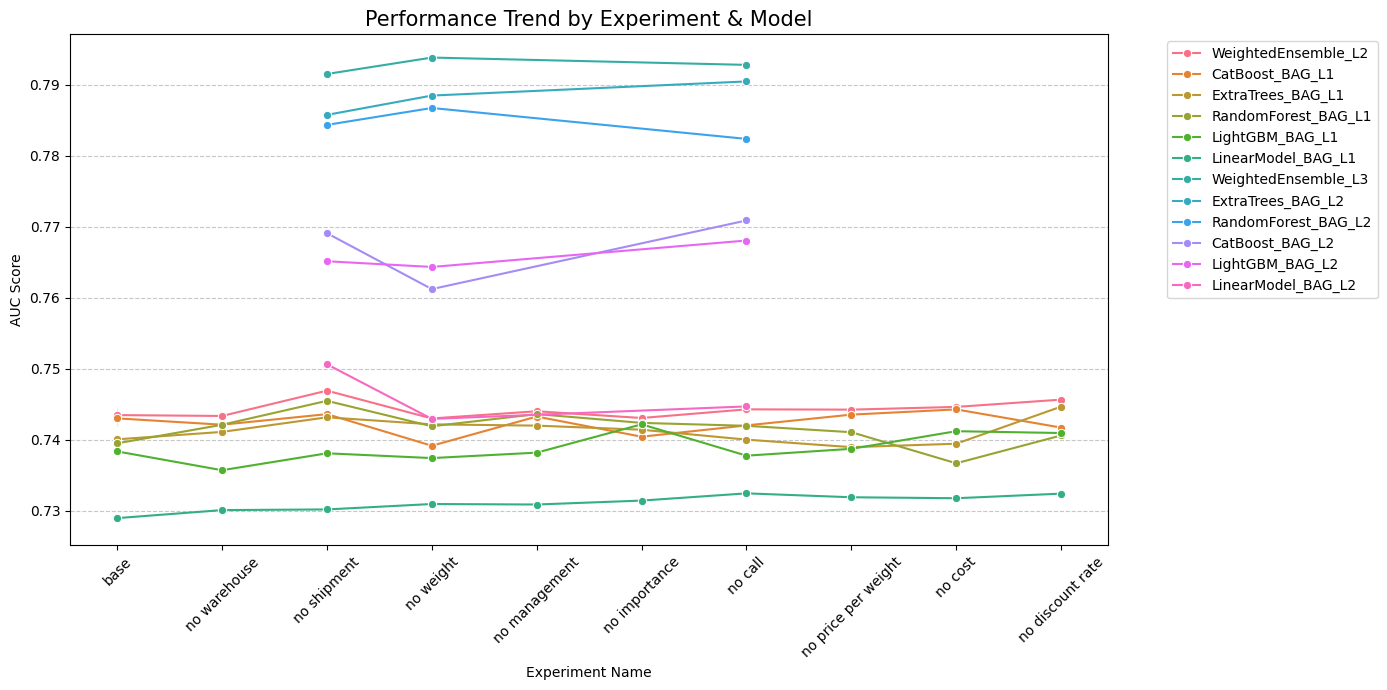


=== 앙상블 모델(최종 모델) 성능 비교 ===


,Experiment_Name,score_val,Run_Time
30,no weight,0.793804,2026-02-09 17:22:03
54,no call,0.792774,2026-02-09 17:45:46
18,no shipment,0.791492,2026-02-09 17:14:56
24,no shipment,0.746908,2026-02-09 17:14:56
78,no discount rate,0.745643,2026-02-09 19:43:44
72,no cost,0.744619,2026-02-09 19:31:31
6,base,0.744445,2026-02-09 17:07:24
60,no call,0.744275,2026-02-09 17:45:46
66,no price per weight,0.744236,2026-02-09 19:06:31
42,no management,0.744007,2026-02-09 17:35:39


In [65]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파일 로드
save_dir = 'test_result'
save_filename = "full_leaderboard.csv"
save_path = os.path.join(save_dir, save_filename)

if not os.path.exists(save_path):
    print(f"⚠️ 파일이 존재하지 않습니다: {save_path}")
else:
    df = pd.read_csv(save_path)

    # 2. 전체 실험 요약 (실험별 최고 AUC 기록 모델 확인)
    print("=== 🏆 실험별 최고 성능 모델 요약 ===")
    summary = df.sort_values('score_val', ascending=False).drop_duplicates('Experiment_Name')
    display(summary[['Experiment_Name', 'model', 'score_val', 'Run_Time']])

    # 3. 실험별/모델별 성능 추이 시각화
    plt.figure(figsize=(14, 7))
    
    # 모델별로 색상을 다르게 하여 실험 회차별 점수 비교
    sns.lineplot(data=df, x='Experiment_Name', y='score_val', hue='model', marker='o')
    
    plt.title('Performance Trend by Experiment & Model', fontsize=15)
    plt.ylabel('AUC Score')
    plt.xlabel('Experiment Name')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # 시각화 결과 저장
    plt.savefig(os.path.join(save_dir, 'experiment_trend.png'))
    plt.show()

    # 4. 특정 모델(예: WeightedEnsemble)만 필터링해서 보기
    print("\n=== 앙상블 모델(최종 모델) 성능 비교 ===")
    ensemble_df = df[df['model'].str.contains('WeightedEnsemble')]
    display(ensemble_df[['Experiment_Name', 'score_val', 'Run_Time']].sort_values('score_val', ascending=False))

Computing feature importance via permutation shuffling for 9 features using 5000 rows with 5 shuffle sets...
	9.74s	= Expected runtime (1.95s per shuffle set)
	1.98s	= Actual runtime (Completed 5 of 5 shuffle sets)


=== 🌟 상위 5개 핵심 변수 ===
Weight_Category     0.160965
Discount_Group      0.109541
Discounted_price    0.085637
Prior_purchases     0.072847
Discount_rate       0.069082
Name: importance, dtype: float64

=== 📉 하위 5개 미미한 변수 ===
Discount_rate              0.069082
log_price_per_weight       0.062349
log_price_per_weight_sq    0.051922
Wh_Shipment_Combo          0.045859
Management_score_sq        0.027398
Name: importance, dtype: float64


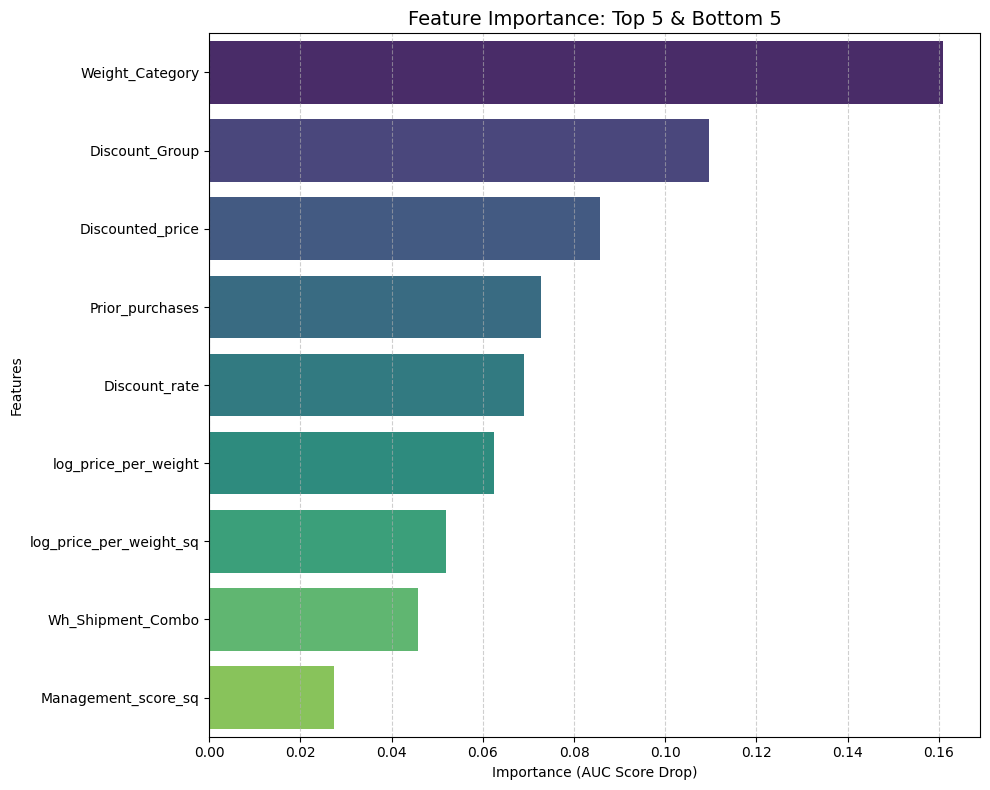

In [66]:
# 1. 변수 중요도 계산 (전체 selected_cols 대상)
# model='WeightedEnsemble_L2' 처럼 특정 모델을 지정할 수도 있습니다.
importance_df = predictor.feature_importance(train_df[selected_cols])

# 2. 상위 5개 & 하위 5개 변수 추출
top_5 = importance_df.head(5)
bottom_5 = importance_df.tail(5)
top_bottom_5 = pd.concat([top_5, bottom_5])

# 3. 시각화 (표보다는 막대그래프가 직관적입니다)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
# 중요도 수치에 따라 색상을 다르게 적용 (상위는 초록, 하위는 빨강 계열)
colors = sns.color_palette("viridis", len(top_bottom_5))
sns.barplot(x=top_bottom_5['importance'], y=top_bottom_5.index, palette=colors)

plt.title('Feature Importance: Top 5 & Bottom 5', fontsize=14)
plt.xlabel('Importance (AUC Score Drop)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# 4. 결과 저장
plt.savefig(os.path.join(save_dir, f'importance_{current_experiment_name}.png'))
top_bottom_5.to_csv(os.path.join(save_dir, f'importance_{current_experiment_name}.csv'))

print("=== 🌟 상위 5개 핵심 변수 ===")
print(top_5['importance'])
print("\n=== 📉 하위 5개 미미한 변수 ===")
print(bottom_5['importance'])